# ⚡ Concurrent Agent Workflows with Azure OpenAI (Python)

## 📋 Advanced Parallel Processing Tutorial

This notebook demonstrates **concurrent workflow patterns** using the Microsoft Agent Framework. You'll learn how to build high-performance, parallel processing workflows where multiple AI agents execute simultaneously, dramatically improving throughput and enabling sophisticated multi-threaded business processes.

## 🎯 Learning Objectives

### 🚀 **Concurrent Processing Fundamentals**
- **Parallel Agent Execution**: Run multiple agents simultaneously for maximum efficiency
- **Workflow Orchestration**: Coordinate concurrent operations while maintaining data consistency
- **Performance Optimization**: Achieve significant speedup through parallel processing
- **Resource Management**: Efficiently utilize AI model resources across concurrent operations

### 🏗️ **Advanced Concurrency Patterns**
- **Fork-Join Processing**: Split work across multiple agents and merge results
- **Pipeline Parallelism**: Overlapping execution stages for continuous throughput
- **Load Balancing**: Distribute work evenly across available agent resources
- **Synchronization Points**: Coordinate concurrent agents at critical workflow stages

### 🏢 **Enterprise Concurrent Applications**
- **High-Volume Document Processing**: Process multiple documents simultaneously
- **Real-Time Content Analysis**: Concurrent analysis of incoming data streams
- **Batch Processing Optimization**: Maximize throughput for large-scale operations
- **Multi-Modal Analysis**: Parallel processing of different content types (text, images, data)

## ⚙️ Prerequisites & Setup

### 📦 **Required Dependencies**

Install Agent Framework with concurrent workflow capabilities:

```bash
pip install agent-framework-core -U
```

### 🔑 **Azure OpenAI Configuration**

**Environment Setup (.env file):**
```env
AZURE_OPENAI_ENDPOINT=https://your-resource.openai.azure.com/
AZURE_OPENAI_CHAT_DEPLOYMENT_NAME=gpt-4o-mini
AZURE_OPENAI_API_KEY=your_azure_openai_api_key
AZURE_OPENAI_API_VERSION=2024-12-01-preview
```

**Concurrent Processing Considerations:**
- **Rate Limits**: Monitor Azure OpenAI API rate limits for concurrent requests
- **Resource Usage**: Consider memory and CPU usage with multiple concurrent agents
- **Error Handling**: Implement robust error recovery for parallel operations

### 🏗️ **Concurrent Workflow Architecture**

```mermaid
graph TD
    A[Workflow Start] --> B[Concurrent Execution]
    B --> C[Agent Pool 1]
    B --> D[Agent Pool 2]
    B --> E[Agent Pool 3]
    C --> F[Result Aggregation]
    D --> F
    E --> F
    F --> G[Final Output]
    
    H[Azure OpenAI API] --> C
    H --> D
    H --> E
```

**Key Benefits:**
- **⚡ Performance**: Significant speedup through parallel execution
- **📈 Scalability**: Handle increased workloads without proportional time increase
- **🔄 Efficiency**: Better utilization of available computational resources
- **🎯 Throughput**: Process more work in the same amount of time

## 🎨 **Concurrent Workflow Design Patterns**

### 🔍 **Research & Analysis Pipeline**
```
Research Task → Parallel Research Agents → Content Synthesis → Quality Review
```

### 📊 **Data Processing Workflow**
```
Input Data → Concurrent Processing Agents → Result Aggregation → Final Report
```

### 🎭 **Content Creation Pipeline**
```
Content Brief → Parallel Content Generators → Review & Merge → Final Content
```

### 🔄 **Multi-Stage Processing**
```
Input → Stage 1 (Concurrent) → Stage 2 (Concurrent) → Stage 3 (Sequential) → Output
```

Let's build high-performance concurrent AI workflows! 🚀

In [1]:
# ✅ Dependencies installed via terminal:
# uv venv .venv --python 3.13
# uv pip install ipykernel --python .venv/Scripts/python.exe
# uv pip install -r Installation/requirements.txt --python .venv/Scripts/python.exe
#
# Select the .venv kernel in VS Code to use these packages.

In [2]:
import os
from typing import Any

from dotenv import load_dotenv, find_dotenv
from agent_framework import Message, WorkflowViz
from agent_framework.orchestrations import ConcurrentBuilder
from agent_framework.openai import OpenAIChatCompletionClient

load_dotenv(find_dotenv())

True

In [3]:
chat_client = OpenAIChatCompletionClient(
    azure_endpoint=os.environ.get("AZURE_OPENAI_ENDPOINT"),
    model=os.environ.get("AZURE_OPENAI_CHAT_DEPLOYMENT_NAME"),
    api_key=os.environ.get("AZURE_OPENAI_API_KEY"),
    api_version=os.environ.get("AZURE_OPENAI_API_VERSION"),
)

In [4]:
ResearcherAgentName = "Researcher-Agent"
ResearcherAgentInstructions = "You are my travel researcher, working with me to analyze the destination, list relevant attractions, and make detailed plans for each attraction."

In [5]:
PlanAgentName = "Plan-Agent"
PlanAgentInstructions = "You are my travel planner, working with me to create a detailed travel plan based on the researcher's findings."

In [6]:
research_agent   = chat_client.as_agent(
        instructions=(
           ResearcherAgentInstructions
        ),
        name=ResearcherAgentName,
    )

plan_agent = chat_client.as_agent(
        instructions=(
            PlanAgentInstructions
        ),
        name=PlanAgentName,
    )

In [7]:
workflow = ConcurrentBuilder(participants=[research_agent, plan_agent]).build()

In [8]:
# Workflow visualization (Mermaid output only — SVG export requires Graphviz system binary, not needed to run the workflow)
print("Generating workflow visualization...")
viz = WorkflowViz(workflow)
print("Mermaid string: \n=======")
print(viz.to_mermaid())
print("=======")

# SVG export — not needed, requires graphviz system binary (winget install --id Graphviz.Graphviz)
# svg_file = viz.export(format="svg")
# print(f"SVG file saved to: {svg_file}")

Generating workflow visualization...
Mermaid string: 
flowchart TD
  dispatcher["dispatcher (Start)"];
  Researcher_Agent["Researcher-Agent"];
  Plan_Agent["Plan-Agent"];
  aggregator["aggregator"];
  fan_in__aggregator__69d73de8((fan-in))
  Plan_Agent --> fan_in__aggregator__69d73de8;
  Researcher_Agent --> fan_in__aggregator__69d73de8;
  fan_in__aggregator__69d73de8 --> aggregator;
  dispatcher --> Researcher_Agent;
  dispatcher --> Plan_Agent;


Attempting to display SVG file at: /var/folders/ks/qm494rx136xfcp7hbsp62l300000gn/T/tmpd9rphgg7.svg


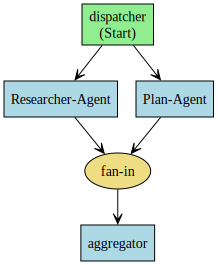

In [ ]:
# SVG display — not needed, requires graphviz system binary
# from IPython.display import SVG, display, HTML
# if svg_file and os.path.exists(svg_file):
#     display(SVG(filename=svg_file))

In [9]:
events = await workflow.run("Plan a trip to Seattle in December")
outputs = events.get_outputs()

In [10]:
if outputs:
        print("===== Final Aggregated Conversation (messages) =====")
        for output in outputs:
            messages: list[Message] | Any = output
            for i, msg in enumerate(messages, start=1):
                name = msg.author_name if msg.author_name else "user"
                print(f"{'-' * 60}\n\n{i:02d} [{name}]:\n{msg.text}")

===== Final Aggregated Conversation (messages) =====
------------------------------------------------------------

01 [user]:
Plan a trip to Seattle in December
------------------------------------------------------------

02 [Researcher-Agent]:
Great choice—Seattle in December is cozy, festive, and full of excellent indoor culture with just enough crisp waterfront air to feel wintry. Below is a destination snapshot, a list of the most relevant attractions, detailed “how to visit” plans for each, a sample itinerary, and practical tips. At the end I’ll ask a few questions so I can tailor this to your dates and interests.

December snapshot
- Weather: Cool and damp. Highs around 45°F/7°C, lows around 37°F/3°C. Expect frequent light rain or drizzle, occasional wind; snow in the city is uncommon but possible.
- Daylight: About 8–9 hours (sunset ~4:15 pm near the solstice). Front-load outdoor sights and plan indoor evenings.
- Crowds and prices: Lighter museum lines and generally better hot